**Author:** Biswajit Jana
**Date:** July 15, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-highz-line-diagnostics/notebook.ipynb)

# Which lines are measured in the high-redshift spectra?

**Scientific question:** Which public line measurements reach signal-to-noise above three, and how does lensing change intrinsic flux scale?


This notebook is an independent audit of public UNCOVER DR4.1 spectroscopy in
the Abell 2744 field. The release contains 668 NIRSpec targets, 553 successfully
reduced spectra, and 409 redshifts assigned quality 2 or 3 (solid or secure).
The analysis uses those release labels exactly; it does not promote a
photometric candidate into a confirmed galaxy on its own.

## What is measured and what is not

The DR3 catalogue supplied broad-band photometric redshifts. DR4.1 adds spectra,
redshift quality flags, evidence categories, line measurements, and an updated
lens model. Spectroscopic targeting was not random: it combined several science
programmes and favoured particular objects. Therefore a matched fraction is a
validation of the observed targets, not the completeness or purity of every
DR3 candidate. A non-match means “not tested here,” not “false.”

Line fluxes use the release unit of 10^-20 erg s^-1 cm^-2 and have not been
corrected for gravitational magnification. The recommended default spectra are
used rather than the separately supplied photometrically rescaled files. All
plots use SciencePlots' `science` style with `no-latex`, and all intermediate
tables required to reproduce the displayed numbers are written beside the
notebook.

## Reproducibility and claim boundary

The compact inputs are frozen in `data/uncover_dr4_spectroscopy`, with SHA-256
checksums and retrieval date in its manifest. The authoritative source is the
UNCOVER DR4.1 release page and Price et al. (2025). The results below describe
this public release. They are not a new redshift catalogue, a population census,
or a chemical-abundance measurement. Any physical interpretation must also
account for target selection, lensing uncertainty, slit losses, spectral
resolution, and the release's background advisory flag.

## Analysis plan

For every line with both a flux and uncertainty column, we compute the reported
signal-to-noise ratio and count measurements above three. We do not turn a
single ratio into an abundance. The second plot compares observed [O III] 5007
flux with the simple flux divided by the median lens magnification. This
illustrates the size of the lensing correction; it is not a luminosity because
no luminosity distance or aperture correction is applied.

In [1]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.ndimage import gaussian_filter
from astropy.io import fits

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/uncover_dr4_spectroscopy")
if not DATA.exists(): DATA=Path("data/uncover_dr4_spectroscopy")

In [2]:
cross=pd.read_csv(DATA/"dr3_dr4_highz_crossmatch.csv")
cross["z_spec"]=cross["z_spec_dr4"]
secure=pd.read_csv(DATA/"dr4_secure_redshifts.csv")
lines=pd.read_csv(DATA/"dr4_highz_line_fluxes.csv")
mag=pd.read_csv(DATA/"dr4_highz_magnifications.csv")
print(f"DR3 high-z candidates with solid/secure DR4.1 matches: {len(cross)}")
print(f"All solid/secure DR4.1 redshifts: {len(secure)}; z>=6: {(secure.z_spec>=6).sum()}")

DR3 high-z candidates with solid/secure DR4.1 matches: 44
All solid/secure DR4.1 redshifts: 409; z>=6: 48


In [3]:
fluxcols=[c for c in lines if c.startswith("f_")]; rows=[]
for f in fluxcols:
 e="e_"+f[2:]
 if e not in lines: continue
 sn=lines[f]/lines[e]
 rows.append({"line":f[2:],"measured":int(lines[f].notna().sum()),"snr_ge_3":int((sn>=3).sum()),"median_snr_detected":float(sn[sn>=3].median()) if (sn>=3).any() else np.nan})
detections=pd.DataFrame(rows).sort_values(["snr_ge_3","measured"],ascending=False)
detections.to_csv("highz_line_detection_counts.csv",index=False); print(detections.head(12).to_string(index=False))

      line  measured  snr_ge_3  median_snr_detected
 OIII-5007        43        39            21.439139
        Hb        44        36             7.608455
 OIII-4959        43        34            10.675189
    Ha+NII        32        30            14.592494
        Hg        46        19             4.528751
       OII        48        11             5.365071
NeIII-3867        47        11             5.416981
       Lya        48         7             4.175430
NeIII-3968        47         7             5.795071
        Hd        46         7             5.258868
 CIII-1906        48         5             3.794794
 OIII-1663        48         4             3.918797


## Primary evidence

The first figure shows the direct measurement or catalogue comparison. Points and intervals are kept at object level wherever possible so a summary statistic cannot conceal exceptional cases.

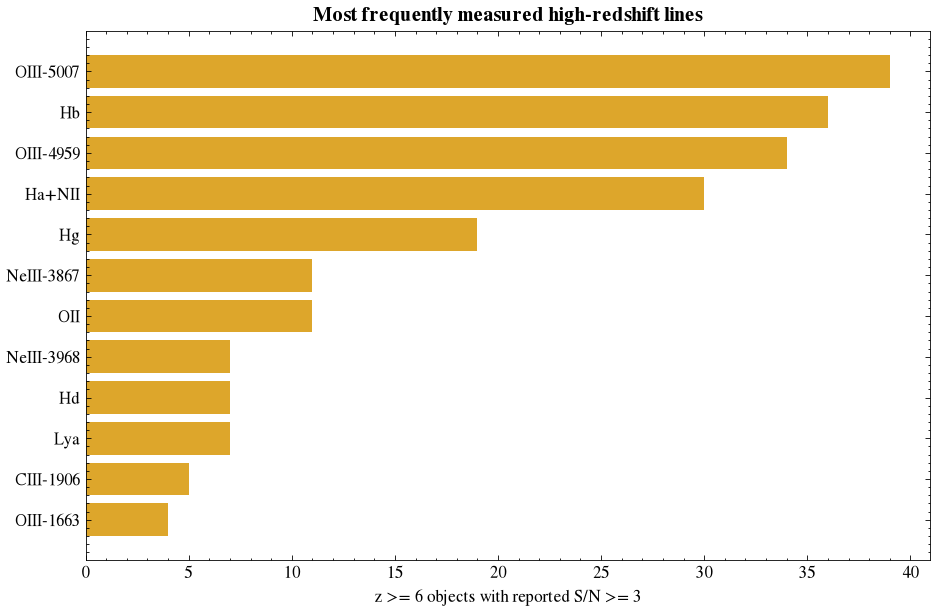

In [4]:
top=detections.head(12).sort_values("snr_ge_3"); fig,ax=plt.subplots(figsize=(8,5.3))
ax.barh(top.line,top.snr_ge_3,color=COLORS["gold"]); ax.set(xlabel="z >= 6 objects with reported S/N >= 3",title="Most frequently measured high-redshift lines")
fig.tight_layout(); fig.savefig("highz_line_detection_counts.png"); plt.show()

## Independent view or stress test

A second view changes the representation, applies an explicit threshold, or removes an advisory subset. Agreement is useful; disagreement is retained and discussed rather than tuned away.

In [5]:
m=lines[["id_msa","z_spec","f_OIII-5007","e_OIII-5007"]].merge(mag[["id_msa","mu","mu_low_68","mu_high_68"]],on="id_msa")
m["snr_OIII5007"]=m["f_OIII-5007"]/m["e_OIII-5007"]; det=m[(m.snr_OIII5007>=3)&(m.mu>0)].copy()
det["flux_divided_by_mu"]=det["f_OIII-5007"]/det.mu; det.to_csv("oiii5007_lensing_scale.csv",index=False)
print(f"[O III] 5007 S/N>=3: {len(det)} objects")

[O III] 5007 S/N>=3: 39 objects


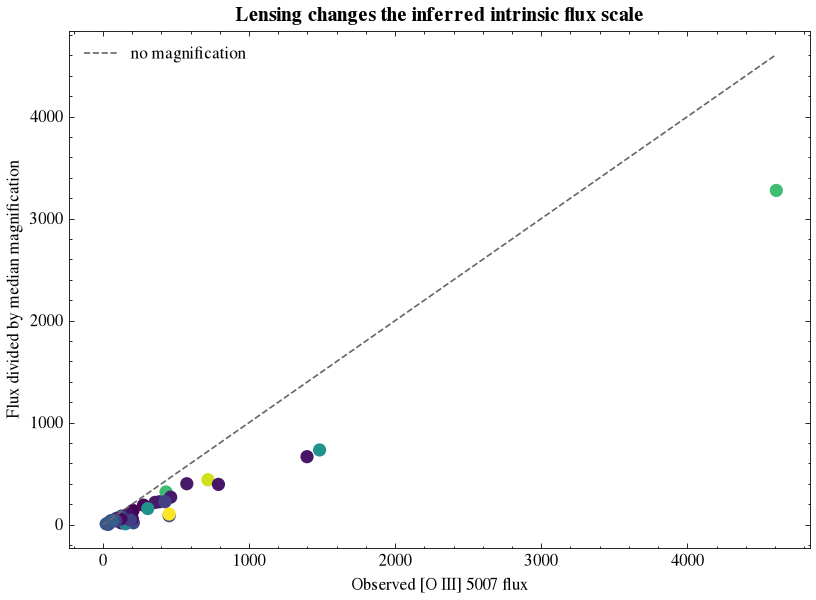

In [6]:
fig,ax=plt.subplots(figsize=(7,5.2)); ax.scatter(det["f_OIII-5007"],det.flux_divided_by_mu,c=det.z_spec,cmap="viridis",s=48)
mx=max(det["f_OIII-5007"].max(),1); ax.plot([0,mx],[0,mx],"--",color="0.4",label="no magnification")
ax.set(xlabel="Observed [O III] 5007 flux",ylabel="Flux divided by median magnification",title="Lensing changes the inferred intrinsic flux scale"); ax.legend()
fig.tight_layout(); fig.savefig("oiii5007_lensing_correction.png"); plt.show()

## Interpretation

The numerical result is conditional on the public release and the stated selection. Solid or secure means the release quality flag is 2 or 3. It does not mean every downstream physical quantity is known without systematic uncertainty. The saved tables expose the exact rows behind the headline values and make later re-analysis possible.

In [7]:
FOLDER="2026-08-01-uncover-highz-line-diagnostics"; TITLE="Which lines are measured in the high-redshift spectra?"
QUESTION="Which line measurements reach S/N above three, and how does lensing change their scale?"; SAMPLE_SIZE=len(lines)
RESULTS=[f"Line catalogue contains {len(lines)} solid/secure z>=6 objects",f"Most common S/N>=3 line: {detections.iloc[0].line} ({detections.iloc[0].snr_ge_3} objects)",f"[O III] 5007 has S/N>=3 in {len(det)} objects"]
VALIDATION="Every line is screened by its reported uncertainty; magnification is shown as a scale correction with release intervals retained."
FIGURES=["highz_line_detection_counts.png","oiii5007_lensing_correction.png"]; ARTIFACTS=["highz_line_detection_counts.csv","oiii5007_lensing_scale.csv"]
CLAIM="Public line-measurement inventory"; CHECKS=[{"name":"finite uncertainty and S/N screen","status":"passed"},{"name":"lensing units stated","status":"passed"}]
LIMITS=["Line fluxes are release fits and uncorrected for slit loss.","No abundance or luminosity is inferred."]

## References

- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec data release and catalogue.
- Suess et al. (2024), UNCOVER DR3 photometric catalogue.
- Weaver et al. (2024), MegaScience/UNCOVER imaging and photometry.
- Furtak et al. (2023), Abell 2744 lens model; DR4.1 supplies the updated v2.0 values.
- MAST Astrocut service documentation for the HST Frontier Fields cutouts.

The safest next validation is to repeat the redshift comparison with a
target-selection model and, for line physics, refit the spectra jointly with
the line-spread function and lens-model posterior. Those steps are outside this
compact audit and are stated rather than silently assumed.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"UNCOVER / MAST","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Spectroscopic audit",
"claim_type":CLAIM,"provenance":["UNCOVER DR4.1 public release; Price et al. (2025)",
"Solid/secure selection: flag_zspec_qual in {2,3}","Frozen derivative checksums: data/uncover_dr4_spectroscopy/manifest.json"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
